In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
# Function to convert ECG signals to spectrogram images
def convert_to_spectrogram(data, fs=250, nperseg=128, img_size=(32, 32)):
    spectrogram_images = []
    
    for signal_data in data:
        # Ensure signal_data is 1D
        signal_data = np.asarray(signal_data).squeeze()
        
        # Handle short signals by padding
        if len(signal_data) < nperseg:
            signal_data = np.pad(signal_data, (0, nperseg - len(signal_data)), 'constant')
        
        # Compute spectrogram
        f, t, Sxx = spectrogram(signal_data, fs=fs, nperseg=nperseg)
        Sxx = np.log(Sxx + 1e-8)  # Log-scale for better visibility
        
        # Resize spectrogram to fixed image size
        img = cv2.resize(Sxx, img_size)
        
        # Normalize the image
        img = (img - np.mean(img)) / np.std(img)
        spectrogram_images.append(img)

    return np.array(spectrogram_images)

In [3]:
def load_ecg_data_from_text_file(file_path):
    try:
        # Read the entire file as text
        with open(file_path, 'r') as file:
            lines = file.readlines()

        ecg_data = []
        labels = []  # Adjust this based on how you want to generate labels

        for line in lines:
            # Split the line by whitespace and try to convert to float
            try:
                values = list(map(float, line.split()))
                if len(values) > 0:  # Ensure there's data in the line
                    ecg_data.append(values)  # Store the ECG signal
                    # Placeholder for label assignment logic
                    labels.append(0)  # Update this to assign actual labels as needed
            except ValueError:
                continue  # Skip lines that cannot be converted to float

        return np.array(ecg_data), np.array(labels)
    
    except Exception as e:
        print(f"Error loading text file {file_path}: {e}")
        return None, None

In [4]:
# Path to your text file
file_path = r'C:\Users\diyu2\OneDrive - AUT University\AUT YEAR 4\INDUSTRIAL PROJECT (Mechanical)\Reports Part B\testing_ecg.txt'

# Load the ECG data from the text file
print("Loading ECG data from text file...")
data, labels = load_ecg_data_from_text_file(file_path)

# Check shapes of loaded data
print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")

Loading ECG data from text file...
Data shape: (5000, 12)
Labels shape: (5000,)


Shape of training data: (4000, 32, 32, 1)
Shape of testing data: (1000, 32, 32, 1)
Shape of labels: (4000,), (1000,)


C:\Users\diyu2\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,465 (619.00 KB)

 Trainable params: 158,465 (619.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.9664 - loss: 0.0588 - val_accuracy: 1.0000 - val_loss: 4.3023e-11
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 1.0000 - loss: 1.3096e-11 - val_accuracy: 1.0000 - val_loss: 4.3014e-11
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 1.0000 - loss: 1.3894e-10 - val_accuracy: 1.0000 - val_loss: 4.3012e-11
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 1.0000 - loss: 2.6830e-10 - val_accuracy: 1.0000 - val_loss: 4.3007e-11
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 2.6042e-10 - val_accuracy: 1.0000 - val_loss: 4.3002e-11
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 1.5176e-10 - val_accuracy: 1.0000 - val_loss: 4.2998e-11
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 6.4341e-11 - val_accuracy: 1.0000 - val_loss: 4.2997e-11
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19

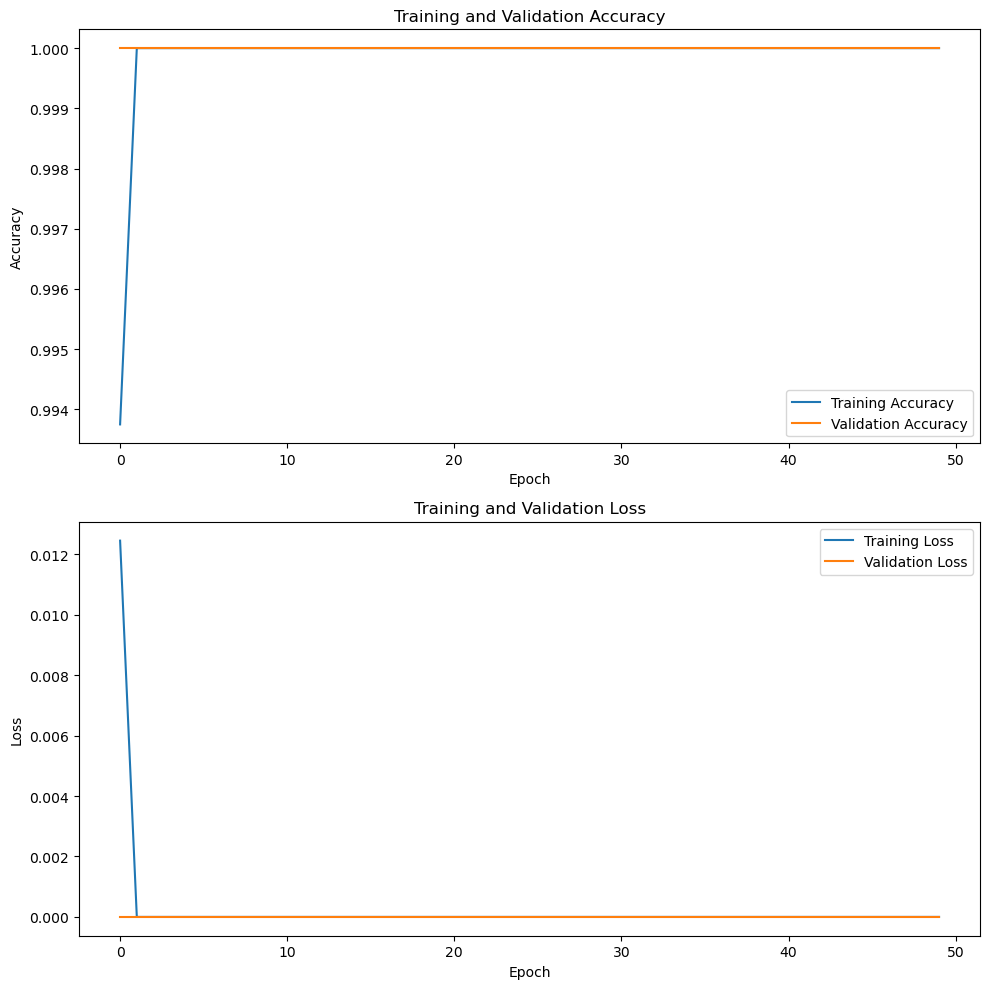

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


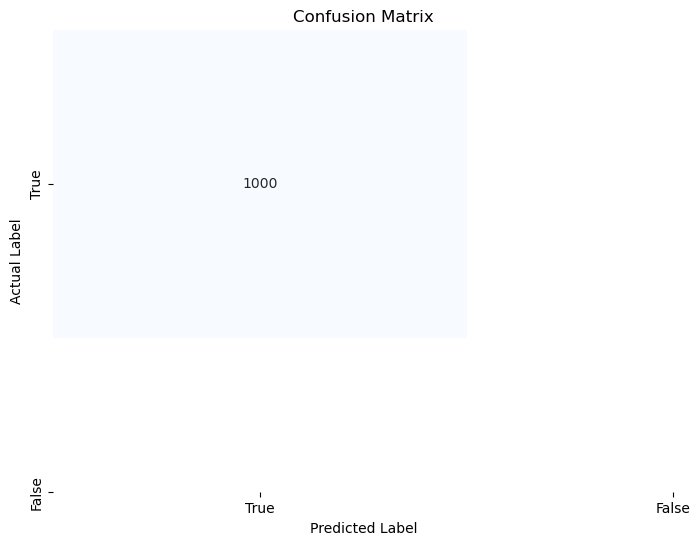

Classification Report:
              precision    recall  f1-score   support

        True       1.00      1.00      1.00      1000
       False       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



In [6]:
# Check if data was loaded successfully
if data is not None:
    # Convert ECG signals to spectrogram images
    spectrogram_images = convert_to_spectrogram(data, fs=250, nperseg=128, img_size=(32, 32))

    # Reshape for CNN: (num_samples, height, width, channels)
    X_spectrograms = spectrogram_images.reshape(spectrogram_images.shape[0], 32, 32, 1)  # Add channel dimension

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_spectrograms, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # Check the shape of the data
    print(f'Shape of training data: {X_train.shape}')
    print(f'Shape of testing data: {X_test.shape}')
    print(f'Shape of labels: {y_train.shape}, {y_test.shape}')

    # Build the CNN model
    model = Sequential([
        Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(np.unique(labels)), activation='sigmoid')  # Adjust for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Display the model architecture
    model.summary()

    # Early stopping to prevent overfitting
    from tensorflow.keras.callbacks import EarlyStopping
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate the model on the test data
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'\nTest Accuracy: {test_acc * 100:.2f}%')

    # Plotting the training and validation accuracy and loss
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))

    # Accuracy plot
    axs[0].plot(history.history['accuracy'], label='Training Accuracy')
    axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_title('Training and Validation Accuracy')
    axs[0].legend(loc='lower right')

    # Loss plot
    axs[1].plot(history.history['loss'], label='Training Loss')
    axs[1].plot(history.history['val_loss'], label='Validation Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Training and Validation Loss')
    axs[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # Predict on the test set
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Confusion matrix plotting function
    def plot_confusion_matrix(y_true, y_pred, class_names):
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                    xticklabels=class_names, yticklabels=class_names)
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.title('Confusion Matrix')
        plt.show()

    # Define class names based on your dataset
    class_names = ['True', 'False']  # Modify based on your actual classes

    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred, class_names)

    # Classification report for additional metrics
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, labels=[0, 1], zero_division=0))
else:
    print("No data loaded.")

Loading ECG data from text file...
Data shape: (5000, 12)
Labels shape: (5000,)


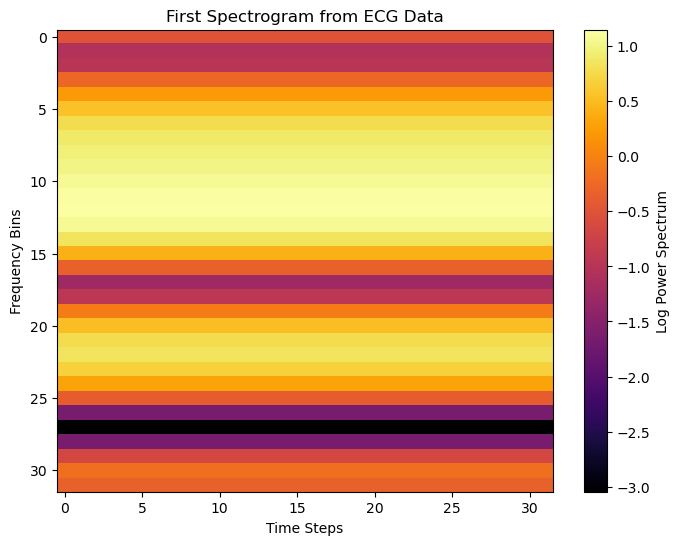

Shape of training data: (4000, 32, 32, 1)
Shape of testing data: (1000, 32, 32, 1)
Shape of labels: (4000,), (1000,)


C:\Users\diyu2\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,465 (619.00 KB)

 Trainable params: 158,465 (619.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9747 - loss: 0.0532 - val_accuracy: 1.0000 - val_loss: 1.1680e-12
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 8.8643e-14 - val_accuracy: 1.0000 - val_loss: 1.1678e-12
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 1.0000 - loss: 4.7431e-13 - val_accuracy: 1.0000 - val_loss: 1.1678e-12
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 1.0000 - loss: 1.8220e-12 - val_accuracy: 1.0000 - val_loss: 1.1678e-12
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 9.8205e-13 - val_accuracy: 1.0000 - val_loss: 1.1678e-12
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 2.6233e-11 - val_accuracy: 1.0000 - val_loss: 1.1678e-12
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 1.0000 - loss: 1.7484e-12 - val_accuracy: 1.0000 - val_loss: 1.1678e-12
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 1

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 1.0000 - loss: 7.1615e-13 - val_accuracy: 1.0000 - val_loss: 1.1667e-12
Epoch 49/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 1.0000 - loss: 2.4399e-12 - val_accuracy: 1.0000 - val_loss: 1.1667e-12
Epoch 50/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 1.0000 - loss: 5.2339e-13 - val_accuracy: 1.0000 - val_loss: 1.1667e-12

Test Accuracy: 100.00%


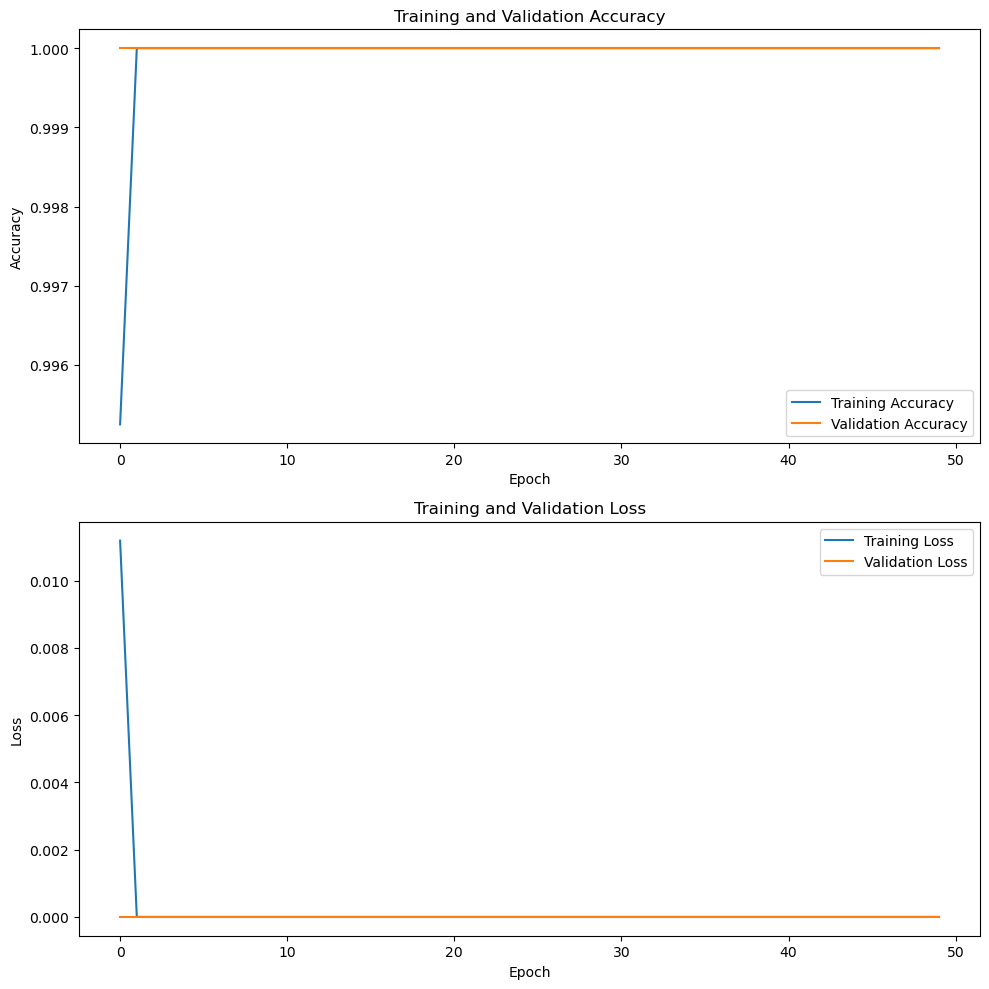

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step


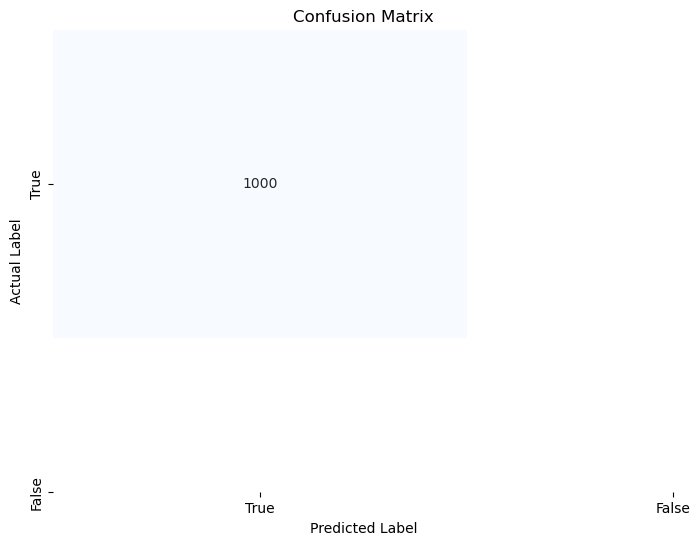

Classification Report:
              precision    recall  f1-score   support

        True       1.00      1.00      1.00      1000
       False       0.00      0.00      0.00         0

   micro avg       1.00      1.00      1.00      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       1.00      1.00      1.00      1000



In [1]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import spectrogram
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Function to convert ECG signals to spectrogram images
def convert_to_spectrogram(data, fs=250, nperseg=128, img_size=(32, 32)):
    spectrogram_images = []
    
    for signal_data in data:
        # Ensure signal_data is 1D
        signal_data = np.asarray(signal_data).squeeze()
        
        # Handle short signals by padding
        if len(signal_data) < nperseg:
            signal_data = np.pad(signal_data, (0, nperseg - len(signal_data)), 'constant')
        
        # Compute spectrogram
        f, t, Sxx = spectrogram(signal_data, fs=fs, nperseg=nperseg)
        Sxx = np.log(Sxx + 1e-8)  # Log-scale for better visibility
        
        # Resize spectrogram to fixed image size
        img = cv2.resize(Sxx, img_size)
        
        # Normalize the image
        img = (img - np.mean(img)) / np.std(img)
        spectrogram_images.append(img)

    return np.array(spectrogram_images)

def load_ecg_data_from_text_file(file_path):
    try:
        # Read the entire file as text
        with open(file_path, 'r') as file:
            lines = file.readlines()

        ecg_data = []
        labels = []  # Adjust this based on how you want to generate labels

        for line in lines:
            # Split the line by whitespace and try to convert to float
            try:
                values = list(map(float, line.split()))
                if len(values) > 0:  # Ensure there's data in the line
                    ecg_data.append(values)  # Store the ECG signal
                    # Placeholder for label assignment logic
                    labels.append(0)  # Update this to assign actual labels as needed
            except ValueError:
                continue  # Skip lines that cannot be converted to float

        return np.array(ecg_data), np.array(labels)
    
    except Exception as e:
        print(f"Error loading text file {file_path}: {e}")
        return None, None

# Path to your text file
file_path = r'C:\Users\diyu2\OneDrive - AUT University\AUT YEAR 4\INDUSTRIAL PROJECT (Mechanical)\Reports Part B\testing_ecg.txt'

# Load the ECG data from the text file
print("Loading ECG data from text file...")
data, labels = load_ecg_data_from_text_file(file_path)

# Check shapes of loaded data
print(f"Data shape: {data.shape}")
print(f"Labels shape: {labels.shape}")

# Check if data was loaded successfully
if data is not None:
    # Convert ECG signals to spectrogram images
    spectrogram_images = convert_to_spectrogram(data, fs=250, nperseg=128, img_size=(32, 32))

    # Visualize the first spectrogram
    plt.figure(figsize=(8, 6))
    plt.imshow(spectrogram_images[0], aspect='auto', cmap='inferno')  # Use a colormap for better visibility
    plt.title('First Spectrogram from ECG Data')
    plt.xlabel('Time Steps')
    plt.ylabel('Frequency Bins')
    plt.colorbar(label='Log Power Spectrum')
    plt.show()

    # Reshape for CNN: (num_samples, height, width, channels)
    X_spectrograms = spectrogram_images.reshape(spectrogram_images.shape[0], 32, 32, 1)  # Add channel dimension

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X_spectrograms, labels, test_size=0.2, random_state=42, stratify=labels
    )

    # Check the shape of the data
    print(f'Shape of training data: {X_train.shape}')
    print(f'Shape of testing data: {X_test.shape}')
    print(f'Shape of labels: {y_train.shape}, {y_test.shape}')

    # Build the CNN model
    model = Sequential([
        Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 1)),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(len(np.unique(labels)), activation='sigmoid')  # Adjust for binary classification
    ])

    # Compile the model
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    # Display the model architecture
    model.summary()

    # Early stopping to prevent overfitting
    from tensorflow.keras.callbacks import EarlyStopping
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    # Train the model
    history = model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=32,
        validation_data=(X_test, y_test),
        callbacks=[early_stop],
        verbose=1
    )

    # Evaluate the model on the test data
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
    print(f'\nTest Accuracy: {test_acc * 100:.2f}%')

    # Plotting the training and validation accuracy and loss
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))

    # Accuracy plot
    axs[0].plot(history.history['accuracy'], label='Training Accuracy')
    axs[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Accuracy')
    axs[0].set_title('Training and Validation Accuracy')
    axs[0].legend(loc='lower right')

    # Loss plot
    axs[1].plot(history.history['loss'], label='Training Loss')
    axs[1].plot(history.history['val_loss'], label='Validation Loss')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Training and Validation Loss')
    axs[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    # Predict on the test set
    y_pred_prob = model.predict(X_test)
    y_pred = (y_pred_prob > 0.5).astype(int)

    # Confusion matrix plotting function
    def plot_confusion_matrix(y_true, y_pred, class_names):
        cm = confusion_matrix(y_true, y_pred)
        
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                    xticklabels=class_names, yticklabels=class_names)
        plt.ylabel('Actual Label')
        plt.xlabel('Predicted Label')
        plt.title('Confusion Matrix')
        plt.show()

    # Define class names based on your dataset
    class_names = ['True', 'False']  # Modify based on your actual classes

    # Plot confusion matrix
    plot_confusion_matrix(y_test, y_pred, class_names)

    # Classification report for additional metrics
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=class_names, labels=[0, 1], zero_division=0))
else:
    print("No data loaded.")
